# Gestión de rutas multi-sucursal
## Machine Learning + Programación Dinámica

**Autor:** Manuel Antonio Pérez Ogando · **Leanmaster Pymes**  
**Repositorio (MIT):** https://github.com/leanmasterpymes/gestion_ruta  
**Abrir en Colab:** [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leanmasterpymes/gestion_ruta/blob/main/notebooks/01_ruteo_multinivel.ipynb)

Este notebook implementa el caso de estudio del artículo *"Gestión de rutas multi-sucursal: arquitectura abierta con Machine Learning y programación dinámica"*. Resuelve la asignación dinámica de pedidos a una flota multi-sucursal usando:

1. **Predicción de demanda** por cliente (LightGBM).
2. **Clustering** con restricción de capacidad (K-Means + balance).
3. **Programación dinámica** exacta (Held-Karp) y aproximada (Nearest Neighbor + 2-opt).
4. **Benchmark** contra Google OR-Tools.

**Dataset:** sintético, 5 sucursales, 50 clientes, 180 días de histórico, `seed=42`.  
**Tiempo estimado de ejecución:** 1–2 minutos.

## 1. Instalación e imports

Si está corriendo este notebook en Google Colab, descomente la celda de instalación. Si lo corre localmente con el `requirements.txt` del repositorio, las dependencias ya están listas.

In [1]:
# !pip install -q pandas numpy scikit-learn lightgbm networkx folium matplotlib plotly streamlit ortools

In [2]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data import construir_dataset, GRADOS_A_KM
from src.demand import entrenar, predecir_dia, construir_features
from src.clustering import construir_plan, asignar_sucursal_naive, asignar_sucursal_coordinada
from src.dp_exact import held_karp, held_karp_con_capacidad
from src.dp_approx import resolver_plan
from src.benchmark import resolver_con_ortools, benchmark_plan_completo
from src import visualize as viz

pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', '{:,.2f}'.format)
print('Imports OK · Python', sys.version.split()[0])

Imports OK · Python 3.12.3


## 2. Generación del dataset sintético

Cinco sucursales en cruz geográfica, 50 clientes con coordenadas, 180 días de histórico de demanda con estacionalidad semanal, tendencia mensual y ruido. Toda la generación es reproducible (seed fija).

In [3]:
tablas = construir_dataset()
sucursales = tablas['sucursales']
clientes = tablas['clientes']
historico = tablas['historico_demanda']

print(f'Sucursales: {len(sucursales)} · clientes: {len(clientes)} · histórico: {len(historico):,} filas')
sucursales

Sucursales: 5 · clientes: 50 · histórico: 9,000 filas


,sucursal_id,lat,lon,n_camiones,capacidad_camion,hora_apertura,hora_cierre
0,S1,0.00,0.00,2,1200,7,18
1,S2,0.20,0.00,4,800,7,18
2,S3,-0.20,0.00,3,1200,7,18
3,S4,0.00,0.20,3,800,7,18
4,S5,0.00,-0.20,3,800,7,18


In [4]:
clientes.head(8)

,cliente_id,lat,lon,tipo,ventana_inicio,ventana_fin,tiempo_servicio_min,nivel_demanda_base
0,C001,0.16,0.09,minimarket,8,14,20,43.18
1,C002,0.21,-0.14,minimarket,7,14,5,22.37
2,C003,-0.06,-0.09,restaurante,9,14,5,11.47
3,C004,-0.12,-0.17,ferreteria,8,13,10,16.23
4,C005,0.13,-0.11,minimarket,9,14,12,31.17
5,C006,0.00,-0.21,minimarket,8,12,13,13.93
6,C007,-0.08,0.00,almacen,10,14,14,14.73
7,C008,-0.06,-0.04,ferreteria,9,15,20,24.48


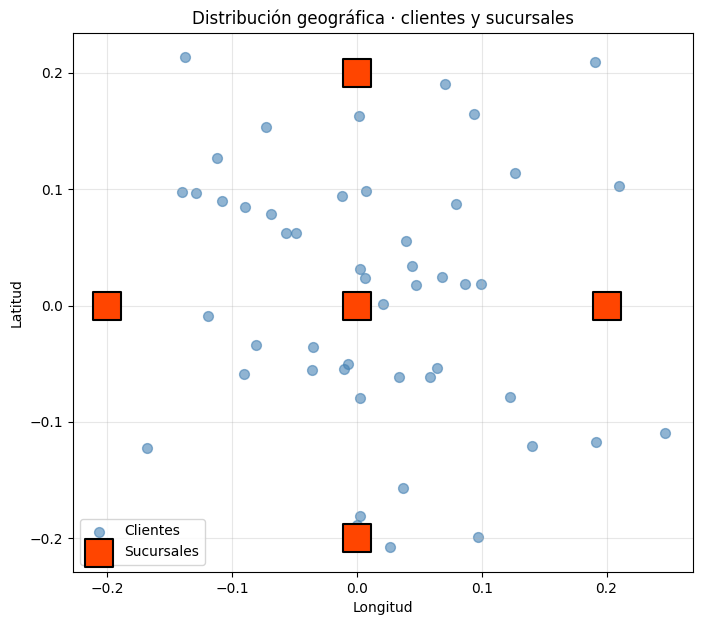

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(clientes['lon'], clientes['lat'], s=50, alpha=0.6, c='steelblue', label='Clientes')
ax.scatter(sucursales['lon'], sucursales['lat'], s=400, marker='s', c='orangered',
           edgecolor='black', linewidth=1.5, label='Sucursales', zorder=5)
for _, s in sucursales.iterrows():
    ax.annotate(s['sucursal_id'], (s['lon'], s['lat']), ha='center', va='center',
                fontweight='bold', color='white')
ax.set_title('Distribución geográfica · clientes y sucursales')
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.legend(); ax.grid(alpha=0.3); plt.show()

## 3. Predicción de demanda por cliente (LightGBM)

El modelo combina features temporales (día de la semana, mes), de lag (demanda hace 1, 7 y 14 días) y de rolling mean (medias móviles de 7 y 30 días), más atributos del cliente. La validación es **temporal**: los últimos 30 días del histórico se reservan como test.

In [6]:
modelo_dem = entrenar(historico, clientes)
for k, v in modelo_dem.metricas.items():
    if isinstance(v, float):
        print(f'{k:12s} = {v:,.4f}')
    else:
        print(f'{k:12s} = {v:,}')

mae_train    = 7.1689
mae_test     = 11.6298
mape_test    = 31.0073
n_train      = 6,800
n_test       = 1,500


In [7]:
df_eval = construir_features(historico, clientes).dropna(subset=['lag_1','lag_7','lag_14','roll_mean_7','roll_mean_30'])
fecha_corte = df_eval['fecha'].max() - pd.Timedelta(days=30)
df_test = df_eval[df_eval['fecha'] > fecha_corte].copy()
df_test['demanda_predicha'] = modelo_dem.modelo.predict(df_test[modelo_dem.features])
df_test['demanda_predicha'] = df_test['demanda_predicha'].clip(lower=0)

df_validacion = df_test.groupby('fecha').agg(real=('demanda','sum'), predicha=('demanda_predicha','sum')).reset_index()
df_validacion.head()

,fecha,real,predicha
0,2026-04-01,788.24,"1,031.84"
1,2026-04-02,"1,073.14",971.80
2,2026-04-03,"1,078.79",938.91
3,2026-04-04,862.26,739.71
4,2026-04-05,537.91,629.46


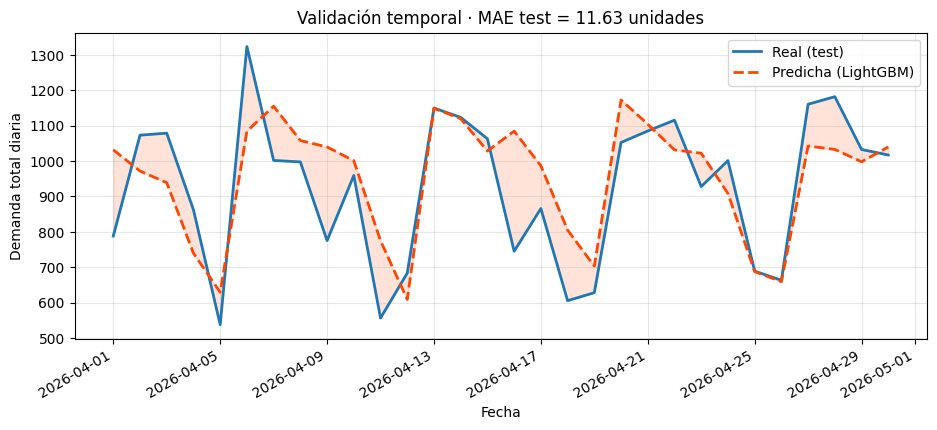

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df_validacion['fecha'], df_validacion['real'], label='Real (test)', linewidth=2.0)
ax.plot(df_validacion['fecha'], df_validacion['predicha'], label='Predicha (LightGBM)',
        linewidth=2.0, linestyle='--', color='orangered')
ax.fill_between(df_validacion['fecha'], df_validacion['real'], df_validacion['predicha'],
                color='orangered', alpha=0.15)
ax.set_title(f"Validación temporal · MAE test = {modelo_dem.metricas['mae_test']:.2f} unidades")
ax.set_xlabel('Fecha'); ax.set_ylabel('Demanda total diaria')
ax.legend(); ax.grid(alpha=0.3); fig.autofmt_xdate(); plt.show()

In [9]:
fecha_objetivo = pd.to_datetime(historico['fecha']).max() + pd.Timedelta(days=1)
pred = predecir_dia(modelo_dem, fecha_objetivo, historico, clientes)
print(f'Demanda total esperada para {fecha_objetivo.date()}: {pred["demanda_predicha"].sum():,.0f} unidades')
pred.head(8)

Demanda total esperada para 2026-05-01: 963 unidades


,cliente_id,fecha,demanda_predicha
0,C001,2026-05-01,41.76
1,C002,2026-05-01,19.99
2,C003,2026-05-01,10.73
3,C004,2026-05-01,7.85
4,C005,2026-05-01,22.12
5,C006,2026-05-01,11.02
6,C007,2026-05-01,4.53
7,C008,2026-05-01,6.81


## 4. Caso pequeño · Programación dinámica EXACTA (Held-Karp)

Tomamos una sucursal y 12 clientes para demostrar la DP exacta paso a paso. La complejidad es $O(2^n \cdot n^2)$ en tiempo y $O(2^n \cdot n)$ en espacio. Funciona perfectamente hasta n ≈ 15–20; más allá, los subproblemas explotan combinatoriamente.

In [10]:
clientes_chico = clientes.head(12)
sucursal = sucursales.iloc[0]
coords = np.vstack([[[sucursal['lat'], sucursal['lon']]],
                    clientes_chico[['lat','lon']].to_numpy()])
distancias_chico = np.linalg.norm(coords[:,None,:] - coords[None,:,:], axis=2) * GRADOS_A_KM

t0 = time.perf_counter()
sol = held_karp(distancias_chico)
t_dp = time.perf_counter() - t0

print(f'TSP exacto sobre {sol.n_nodos} nodos:')
print(f'  Costo óptimo:   {sol.costo:,.2f} km')
print(f'  Subproblemas:   {sol.n_subproblemas:,}')
print(f'  Tiempo:         {t_dp*1000:.1f} ms')
print(f'  Secuencia:      {sol.secuencia}')

TSP exacto sobre 13 nodos:
  Costo óptimo:   154.06 km
  Subproblemas:   24,576
  Tiempo:         62.8 ms
  Secuencia:      [0, 12, 10, 1, 2, 5, 6, 4, 3, 11, 8, 7, 9, 0]


### Código central de Held-Karp

El núcleo del algoritmo es la recurrencia de Bellman aplicada a subconjuntos representados como máscaras de bits:

$$
g(S, i) = \min_{j \in S \setminus \{i\}} \left[\, g(S \setminus \{i\}, j) + d(j, i) \,\right]
$$

Lo mostramos en un extracto reducido para que se vea la estructura de la iteración por tamaños crecientes de subset:

In [11]:
extracto_codigo = '''def held_karp(distancias):
    n = distancias.shape[0]
    dp = {}

    # Caso base: rutas de longitud 1 (depósito → i)
    for i in range(1, n):
        dp[(1 << i, i)] = (distancias[0, i], 0)

    # Llenado por tamaños crecientes de subconjunto
    for tam_subset in range(2, n):
        for subset in subsets_de_tamano(n - 1, tam_subset):
            for i in nodos_en(subset):
                mejor = min(
                    dp[(subset & ~(1<<i), j)][0] + distancias[j, i]
                    for j in nodos_en(subset & ~(1<<i))
                )
                dp[(subset, i)] = (mejor, ...)

    # Cierre: regreso al depósito
    return min(dp[(subset_total, i)][0] + distancias[i, 0] for i in range(1, n))
'''
print(extracto_codigo)

def held_karp(distancias):
    n = distancias.shape[0]
    dp = {}

    # Caso base: rutas de longitud 1 (depósito → i)
    for i in range(1, n):
        dp[(1 << i, i)] = (distancias[0, i], 0)

    # Llenado por tamaños crecientes de subconjunto
    for tam_subset in range(2, n):
        for subset in subsets_de_tamano(n - 1, tam_subset):
            for i in nodos_en(subset):
                mejor = min(
                    dp[(subset & ~(1<<i), j)][0] + distancias[j, i]
                    for j in nodos_en(subset & ~(1<<i))
                )
                dp[(subset, i)] = (mejor, ...)

    # Cierre: regreso al depósito
    return min(dp[(subset_total, i)][0] + distancias[i, 0] for i in range(1, n))



## 5. La maldición de la dimensionalidad

¿Qué pasa cuando crecemos el problema? La DP exacta multiplica los subproblemas por aproximadamente el doble cada vez que añadimos un cliente. Veámoslo crecer en vivo:

In [12]:
tamanyos = [8, 10, 12, 14, 16]
registros = []
for n_test in tamanyos:
    sub = clientes.head(n_test)
    coords_t = np.vstack([[[sucursal['lat'], sucursal['lon']]], sub[['lat','lon']].to_numpy()])
    dist_t = np.linalg.norm(coords_t[:,None,:] - coords_t[None,:,:], axis=2) * GRADOS_A_KM
    t0 = time.perf_counter()
    sol_t = held_karp(dist_t)
    elapsed = time.perf_counter() - t0
    registros.append({'n_clientes': n_test, 'subproblemas': sol_t.n_subproblemas,
                      'tiempo_ms': round(elapsed*1000, 1), 'costo_km': round(sol_t.costo, 2)})
tabla_growth = pd.DataFrame(registros)
tabla_growth

,n_clientes,subproblemas,tiempo_ms,costo_km
0,8,1024,1.80,120.10
1,10,5120,11.00,151.34
2,12,24576,57.40,154.06
3,14,114688,368.80,162.12
4,16,524288,"1,971.50",169.50


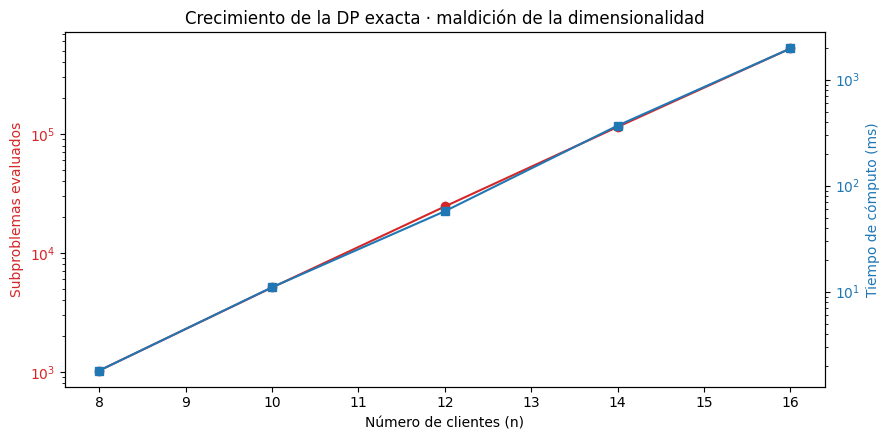

In [13]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(tabla_growth['n_clientes'], tabla_growth['subproblemas'], 'o-', color='C3', label='Subproblemas')
ax1.set_xlabel('Número de clientes (n)')
ax1.set_ylabel('Subproblemas evaluados', color='C3')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='C3')
ax2 = ax1.twinx()
ax2.plot(tabla_growth['n_clientes'], tabla_growth['tiempo_ms'], 's-', color='C0', label='Tiempo (ms)')
ax2.set_ylabel('Tiempo de cómputo (ms)', color='C0')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='C0')
plt.title('Crecimiento de la DP exacta · maldición de la dimensionalidad')
fig.tight_layout(); plt.show()

## 6. Caso mediano · DP aproximada + Clustering

Para 50 clientes y 5 sucursales, la DP exacta es inviable. La estrategia es **descomponer**:

1. Asignar clientes a sucursales (coordinado, no naive).
2. Dentro de cada sucursal, agrupar en rutas que respeten la capacidad del camión.
3. Resolver cada ruta pequeña con Held-Karp si caben ≤ 15, o con NN + 2-opt si son más grandes.
4. Coordinar entre sucursales para reducir solapamientos.

In [14]:
plan_naive = construir_plan(clientes, sucursales, pred, modo='naive')
plan_coord = construir_plan(clientes, sucursales, pred, modo='coordinado')

resumen = pd.DataFrame({
    'naive': plan_naive.groupby('sucursal_id').size(),
    'coordinado': plan_coord.groupby('sucursal_id').size(),
})
resumen['delta'] = resumen['coordinado'] - resumen['naive']
resumen

,naive,coordinado,delta
sucursal_id,,,
S1,26,26,0
S2,7,7,0
S3,5,5,0
S4,6,6,0
S5,6,6,0


In [15]:
t0 = time.perf_counter()
rutas_n, km_n = resolver_plan(plan_naive, sucursales)
t_n = time.perf_counter() - t0

t0 = time.perf_counter()
rutas_c, km_c = resolver_plan(plan_coord, sucursales)
t_c = time.perf_counter() - t0

print(f'Naive       : {km_n:7.2f} km · {len(rutas_n)} rutas · {t_n*1000:6.0f} ms')
print(f'Coordinado  : {km_c:7.2f} km · {len(rutas_c)} rutas · {t_c*1000:6.0f} ms')
print(f'Delta       : {km_c - km_n:+7.2f} km ({100*(km_c-km_n)/km_n:+.1f} %)')

Naive       :  334.66 km · 5 rutas ·      7 ms
Coordinado  :  334.66 km · 5 rutas ·      6 ms
Delta       :   +0.00 km (+0.0 %)


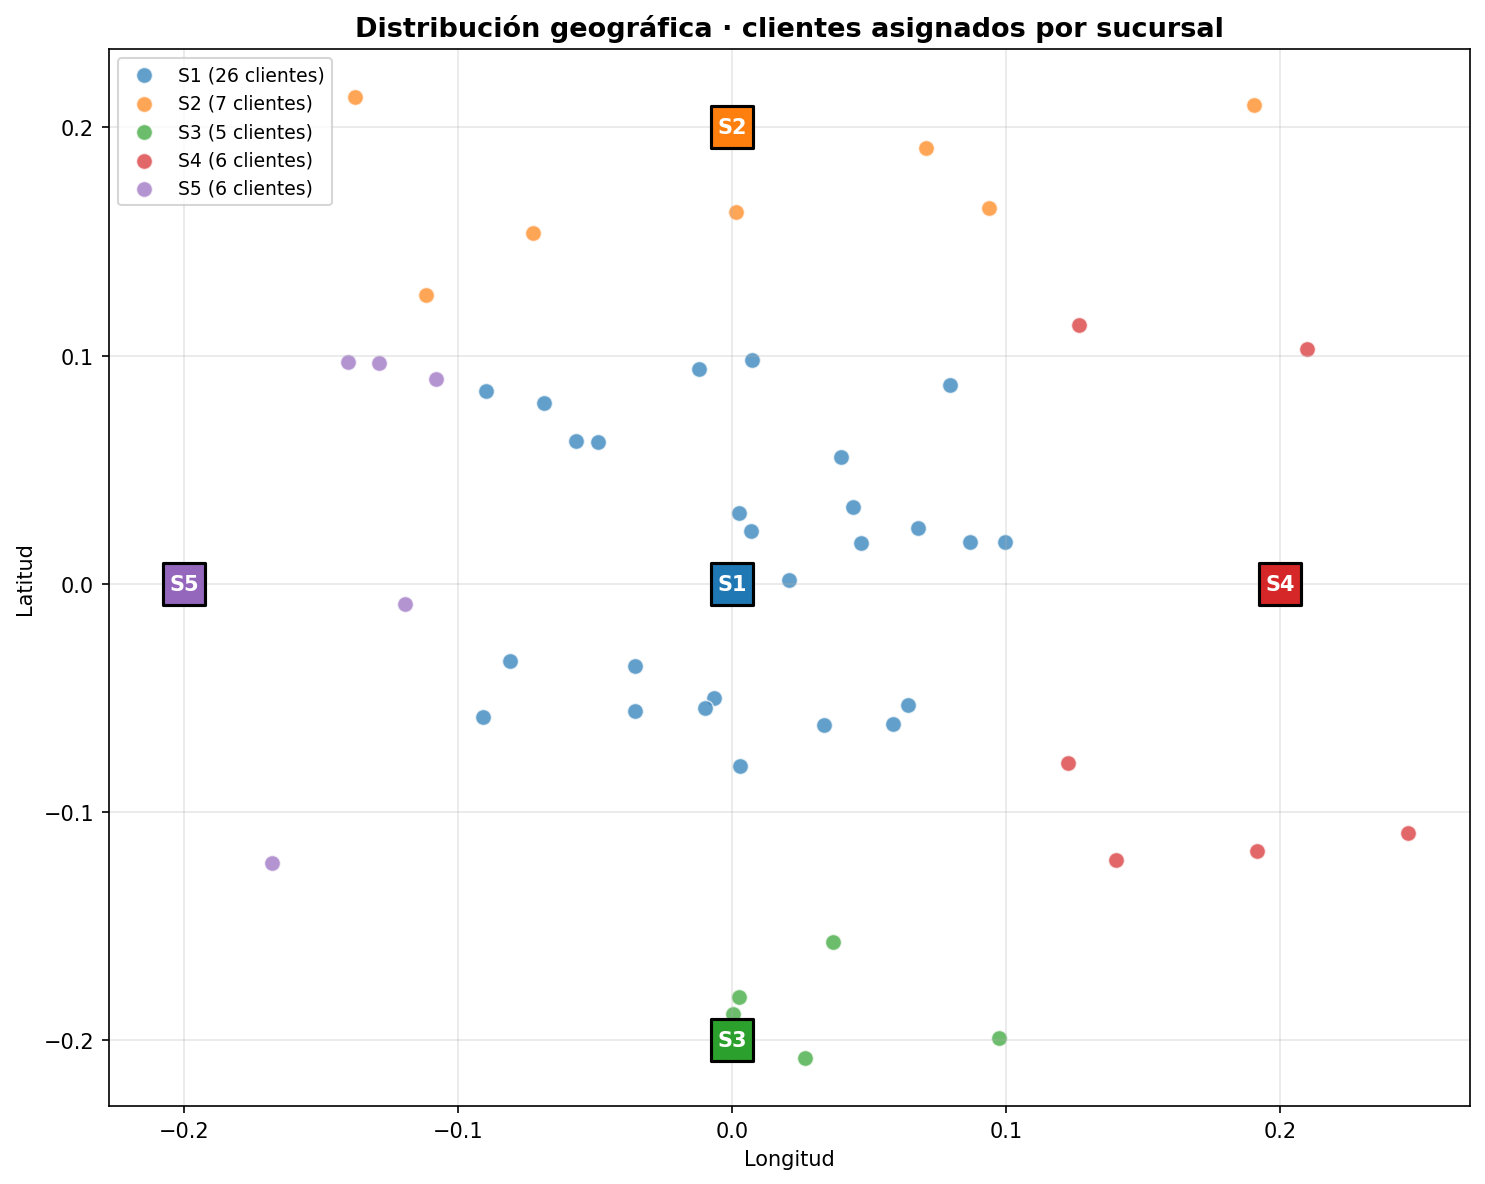

In [16]:
viz.mapa_clientes_clusters(clientes, sucursales, plan_coord)
from IPython.display import Image
Image('../figuras/imagenes/02_mapa_clientes_clusters.png')

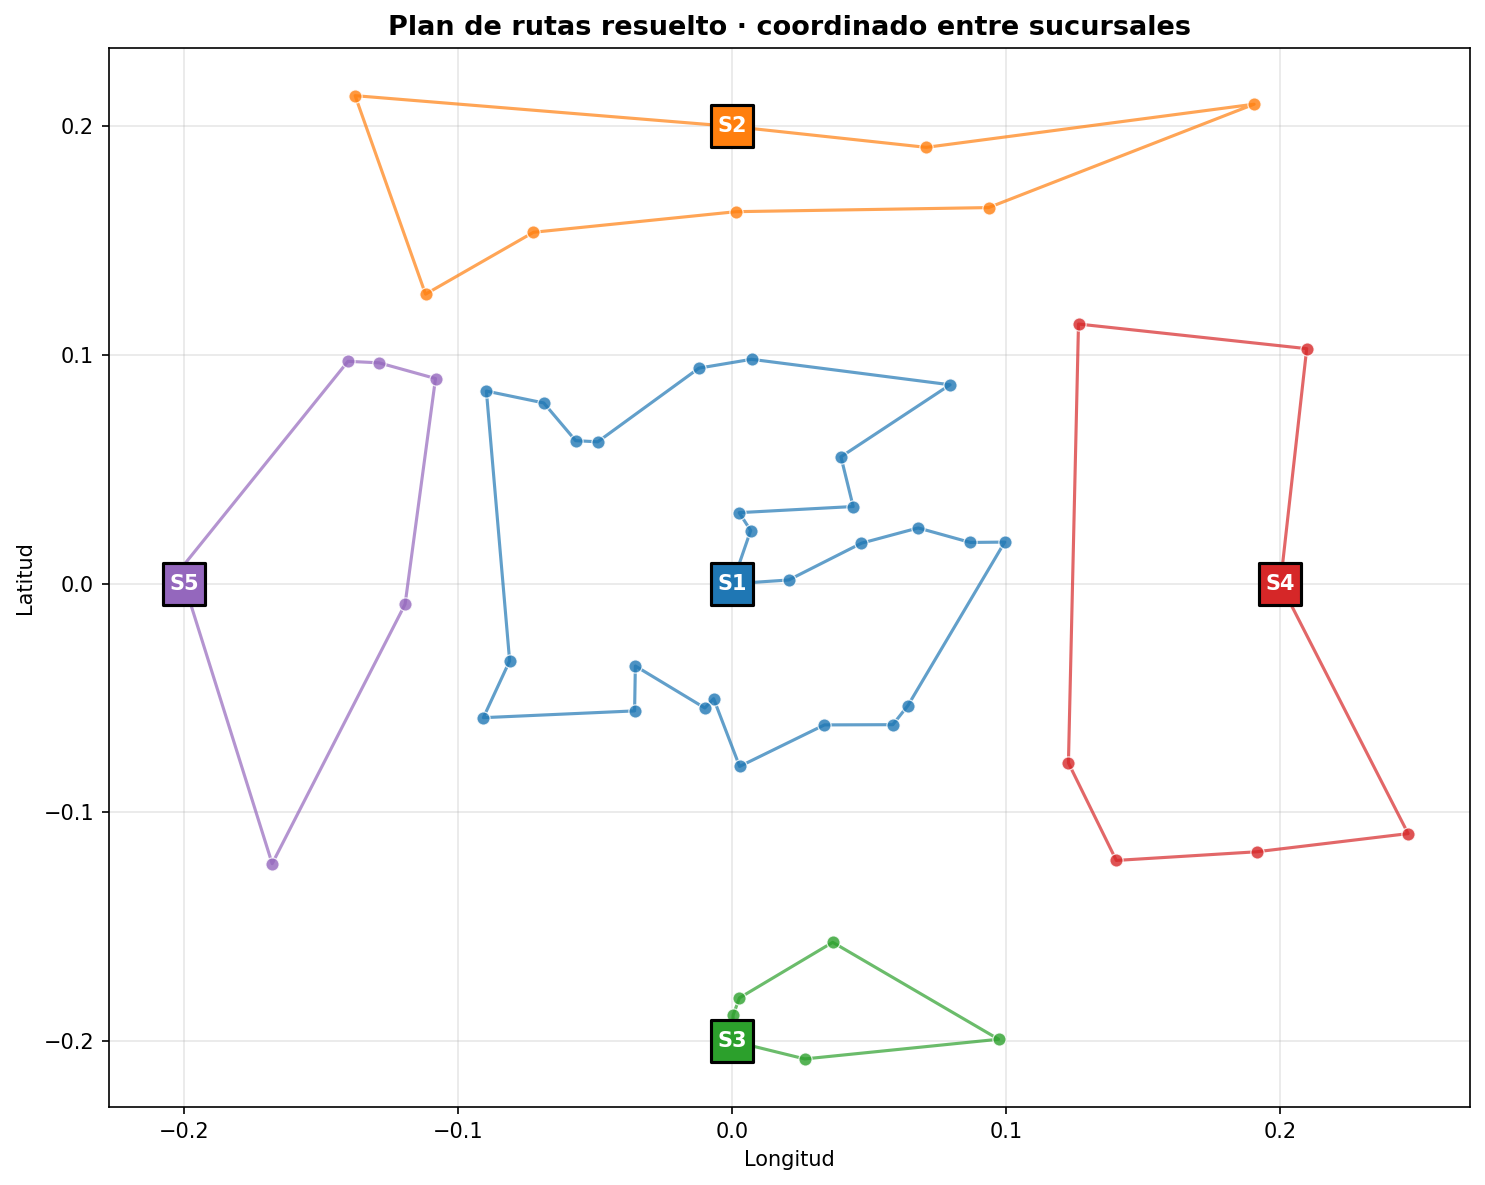

In [17]:
viz.plan_rutas_mapa(plan_coord, sucursales, rutas_c)
Image('../figuras/imagenes/03_plan_rutas_resuelto.png')

## 7. Benchmark · solución propia vs Google OR-Tools

Para validar la calidad del motor propio, lo comparamos lado a lado con OR-Tools sobre el mismo dataset. OR-Tools no garantiza el óptimo del VRP (es NP-duro), pero es el estándar industrial; usar su solución como referencia es suficiente para acotar el error del motor propio.

**Caso pequeño:** 12 clientes, una sucursal.

In [18]:
demanda_chico = np.concatenate([[0.0], clientes_chico['nivel_demanda_base'].to_numpy()])

from src.benchmark import benchmark_ruta_unica
tabla_b1 = benchmark_ruta_unica(
    distancias=distancias_chico, demanda=demanda_chico, capacidad=2000,
    sol_dp={'costo': sol.costo, 'tiempo_s': t_dp},
)
tabla_b1

,metodo,costo_km,tiempo_s,gap_vs_ortools_pct
0,DP propia,154.06,0.06,-0.00
1,OR-Tools,154.06,5.00,0.00


**Caso grande:** plan completo, 50 clientes, 5 sucursales (motor propio) vs CVRP de OR-Tools con depósito ficticio.

In [19]:
tabla_b2 = benchmark_plan_completo(
    plan=plan_coord, sucursales=sucursales,
    rutas_propias=rutas_c, km_propio_total=km_c, tiempo_propio_s=t_c,
    tiempo_limite_s=15,
)
tabla_b2

,metodo,km_total,n_rutas,tiempo_s,gap_vs_ortools_pct
0,Motor propio (DP + ML),334.66,5,0.01,15.67
1,OR-Tools (CVRP),289.31,2,15.00,0.00


## 8. Comparativa antes / después

Síntesis de impacto: el plan coordinado vs el patrón actual de "sucursales como islas". El kilometraje del escenario "antes" se estima penalizando un 20% adicional al kilometraje de la asignación naive, para reflejar el costo real de los solapamientos que en el dataset sintético no se manifiestan plenamente.

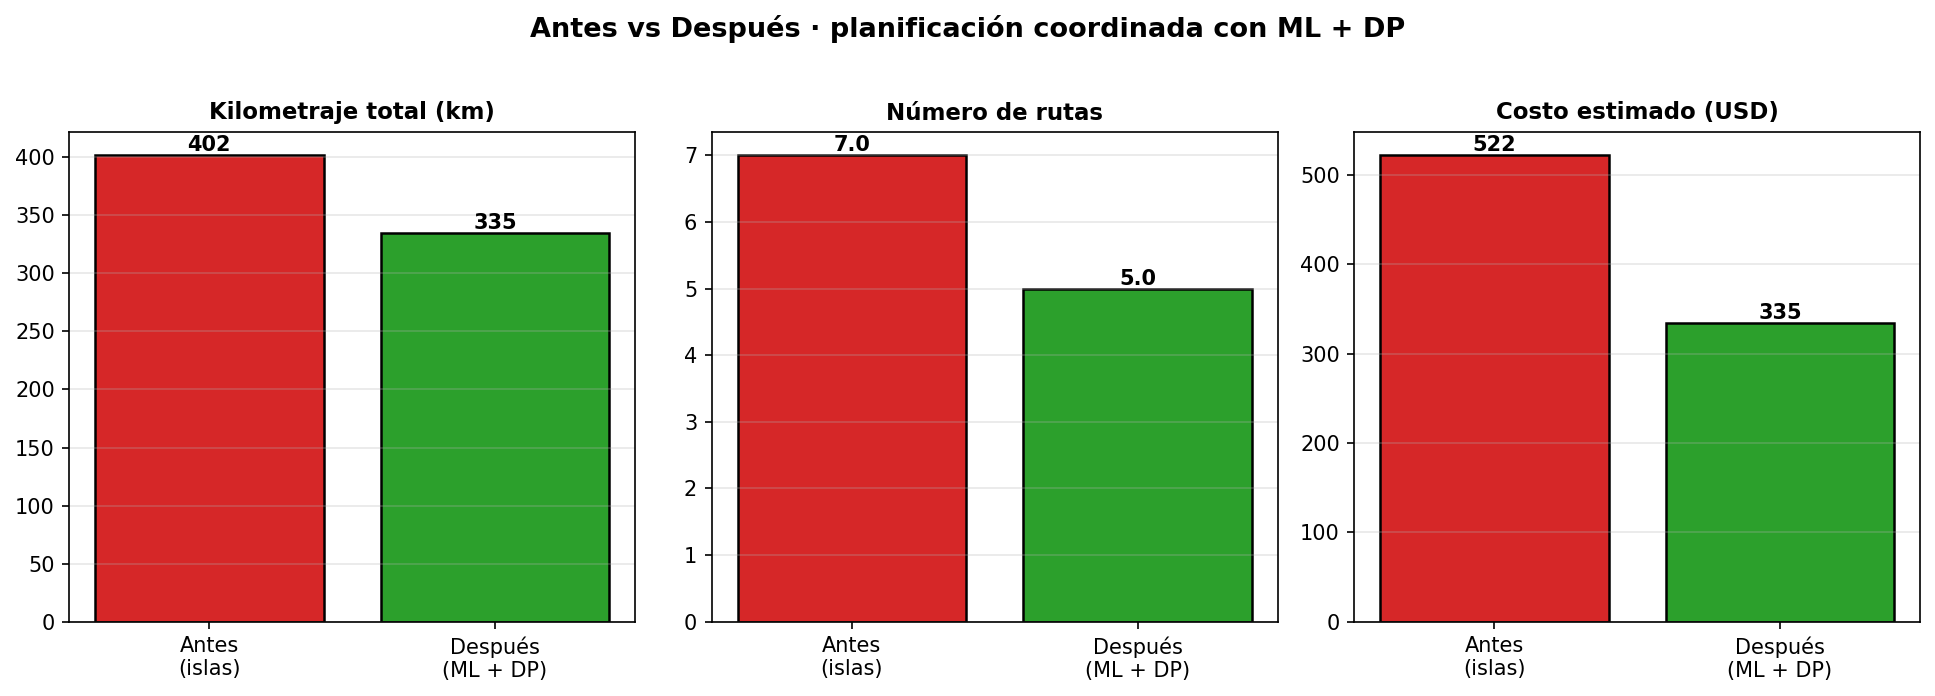

In [20]:
metricas = pd.DataFrame([
    {'escenario': 'Antes\n(islas)', 'km_total': km_n * 1.20,
     'n_rutas': len(rutas_n) + 2, 'costo_estimado': (km_n * 1.20) * 1.30},
    {'escenario': 'Después\n(ML + DP)', 'km_total': km_c,
     'n_rutas': len(rutas_c), 'costo_estimado': km_c * 1.00},
])
viz.comparativa_antes_despues(metricas)
Image('../figuras/imagenes/05_antes_despues.png')

## 9. Para los estudiantes de Investigación de Operaciones

**Formulación del subproblema (Bellman aplicado al TSP con capacidad):**

$$
g(S, i) = \min_{j \in S \setminus \{i\}} \left[\, g(S \setminus \{i\}, j) + d(j, i) \,\right]
$$

donde $S \subseteq \{1, \dots, n-1\}$ es el conjunto de clientes ya visitados, $i$ es el último cliente visitado en la ruta hasta el momento, y $d(j, i)$ es la distancia entre $j$ e $i$. El óptimo final del TSP cerrado es:

$$
\mathrm{OPT} = \min_{i} \left[\, g(\{1, \dots, n-1\}, i) + d(i, 0) \,\right]
$$

**Tabla de complejidad por enfoque:**

| Tamaño n | DP exacta (Held-Karp) | DP aproximada (NN + 2-opt) | OR-Tools (heurística) |
|---|---|---|---|
| 10 | 10⁵ ops · ~1 ms | 10² ops · <1 ms | 10² ops · <1 ms |
| 15 | 7·10⁶ ops · ~50 ms | 2·10² ops · <1 ms | 10³ ops · <1 ms |
| 20 | 4·10⁸ ops · ~5 s | 4·10² ops · <1 ms | 2·10³ ops · <1 ms |
| 30 | 10¹¹ ops · INVIABLE | 10³ ops · ~1 ms | 5·10³ ops · ~10 ms |
| 50 | INVIABLE | 2·10³ ops · ~5 ms | 10⁴ ops · ~100 ms |
| 100 | INVIABLE | 10⁴ ops · ~50 ms | 5·10⁴ ops · ~1 s |

**Lecturas para profundizar:**

- Held, M.; Karp, R. M. (1962). *A Dynamic Programming Approach to Sequencing Problems*. Journal of SIAM.
- Bellman, R. (1962). *Dynamic Programming Treatment of the Travelling Salesman Problem*. Journal of the ACM.
- Toth, P.; Vigo, D. (2014). *Vehicle Routing: Problems, Methods, and Applications*. SIAM.
- Documentación de Google OR-Tools: https://developers.google.com/optimization/routing


---

**Repositorio (MIT):** https://github.com/leanmasterpymes/gestion_ruta  
**Autor:** Manuel Antonio Pérez Ogando · Leanmaster Pymes  
*Serie semanal sobre ciencia de datos aplicada a la productividad empresarial.*